<a href="https://colab.research.google.com/github/FariaZulfiqar/Supply-Chain-Analytics-Portfolio-Faria-Zulfiqar-IBA-Fall2026/blob/main/00-Initial%20working/Initial-Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_excel("Chenab_Motors_Procurement_Practice_Dataset.xlsx")

print(df.shape)
print(df.head())

(33, 3)
  Chenab Motors Limited — Procurement Practice Dataset  \
0  For Google Colab / Python analytics practice —...     
1                                                NaN     
2  ⚠ This is a fully fictional practice dataset. ...     
3                                                NaN     
4                                      Dataset size:     

                                          Unnamed: 1 Unnamed: 2  
0                                                NaN        NaN  
1                                                NaN        NaN  
2                                                NaN        NaN  
3                                                NaN        NaN  
4  10,050 rows (10,000 base transactions + ~50 de...        NaN  


In [11]:
import pandas as pd

# Read the Procurement_Data sheet
df = pd.read_excel(
    "Chenab_Motors_Procurement_Practice_Dataset.xlsx",
    sheet_name="Procurement_Data"
)

# Check the data
print(df.shape)
print(df.head())
print(df.columns.tolist())

(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

In [14]:
import pandas as pd

# Load the Procurement_Data sheet
df = pd.read_excel(
    "Chenab_Motors_Procurement_Practice_Dataset.xlsx",
    sheet_name="Procurement_Data"
)

# Basic Spend Analysis

# 1. Total PO Spend
total_po_spend = df["PO Value (PKR)"].sum()

# 2. Total Number of POs
total_number_of_pos = df["PO Number"].nunique()

# 3. Total Number of Vendors
total_number_of_vendors = df["Vendor ID"].nunique()

# 4. Average PO Value
average_po_value = df.groupby("PO Number")["PO Value (PKR)"].sum().mean()

# 5. Average Line-Item Value
average_line_item_value = df["PO Value (PKR)"].mean()

# Display results
print("===== BASIC SPEND ANALYSIS =====")
print(f"Total PO Spend:          PKR {total_po_spend:,.2f}")
print(f"Total Number of POs:     {total_number_of_pos:,}")
print(f"Total Number of Vendors: {total_number_of_vendors:,}")
print(f"Average PO Value:        PKR {average_po_value:,.2f}")
print(f"Average Line-Item Value: PKR {average_line_item_value:,.2f}")

===== BASIC SPEND ANALYSIS =====
Total PO Spend:          PKR 614,670,044.11
Total Number of POs:     7,406
Total Number of Vendors: 60
Average PO Value:        PKR 82,996.23
Average Line-Item Value: PKR 61,161.20


===== TOP 10 VENDORS BY SPEND =====


,Vendor,Total PO Spend (PKR)
0,Al-Amin Auto Components,1.018835e+08
1,Karachi Steel Traders,5.007253e+07
2,Zaman Brothers Trading,3.586614e+07
3,Anwar Electric Works,3.146678e+07
4,TCS Cargo Services,2.703754e+07
5,Gulistan Logistics,1.972002e+07
6,Speedline Logistics,1.750654e+07
7,Sindh Spinners Co.,1.655498e+07
8,United Rubber Industries,1.587658e+07
9,Modern Fasteners Co.,1.338250e+07


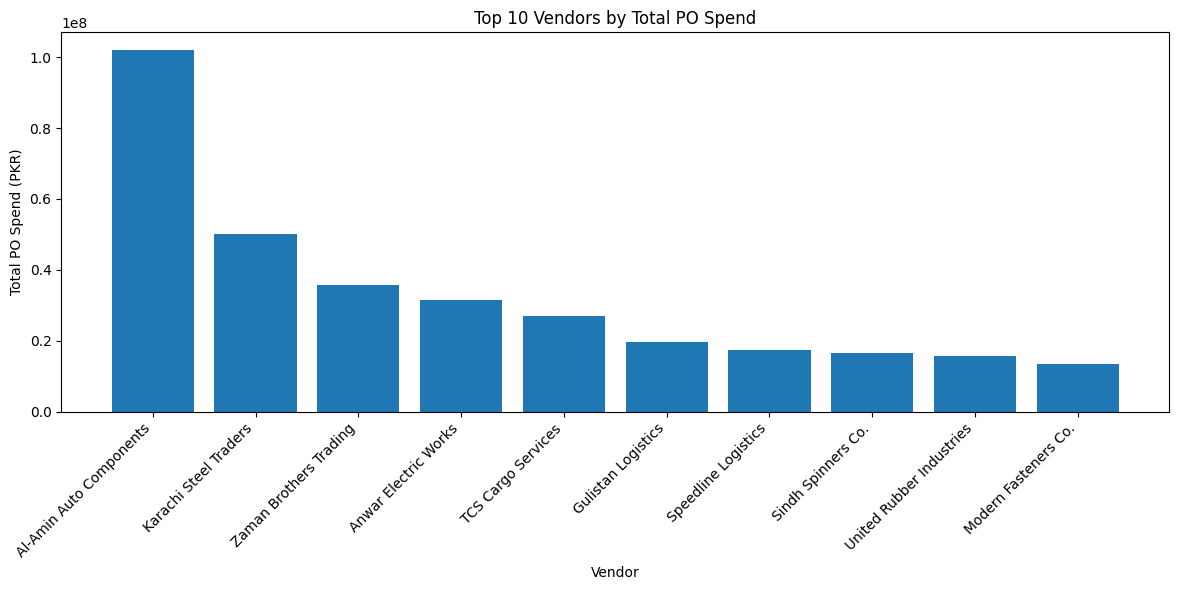

In [15]:
import matplotlib.pyplot as plt

# Calculate total PO Value for each vendor
top_10_vendors = (
    df.groupby("Vendor")["PO Value (PKR)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Rename column for easier reading
top_10_vendors.columns = ["Vendor", "Total PO Spend (PKR)"]

# Display the results as a table
print("===== TOP 10 VENDORS BY SPEND =====")
display(top_10_vendors)

# Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_vendors["Vendor"],
    top_10_vendors["Total PO Spend (PKR)"]
)

plt.title("Top 10 Vendors by Total PO Spend")
plt.xlabel("Vendor")
plt.ylabel("Total PO Spend (PKR)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

===== VENDOR PARETO ANALYSIS =====


,Vendor Rank,Vendor,PO Value (PKR),Spend Percentage,Cumulative Spend Percentage
0,1,Al-Amin Auto Components,1.018835e+08,16.750597,16.750597
1,2,Karachi Steel Traders,5.007253e+07,8.232389,24.982986
2,3,Zaman Brothers Trading,3.586614e+07,5.896728,30.879713
3,4,Anwar Electric Works,3.146678e+07,5.173431,36.053145
4,5,TCS Cargo Services,2.703754e+07,4.445224,40.498369
5,6,Gulistan Logistics,1.972002e+07,3.242155,43.740523
6,7,Speedline Logistics,1.750654e+07,2.878239,46.618762
7,8,Sindh Spinners Co.,1.655498e+07,2.721793,49.340554
8,9,United Rubber Industries,1.587658e+07,2.610258,51.950812
9,10,Modern Fasteners Co.,1.338250e+07,2.200208,54.151020



===== VENDORS CONTRIBUTING APPROXIMATELY 80% OF TOTAL SPEND =====


,Vendor Rank,Vendor,PO Value (PKR),Spend Percentage,Cumulative Spend Percentage
0,1,Al-Amin Auto Components,1.018835e+08,16.750597,16.750597
1,2,Karachi Steel Traders,5.007253e+07,8.232389,24.982986
2,3,Zaman Brothers Trading,3.586614e+07,5.896728,30.879713
3,4,Anwar Electric Works,3.146678e+07,5.173431,36.053145
4,5,TCS Cargo Services,2.703754e+07,4.445224,40.498369
5,6,Gulistan Logistics,1.972002e+07,3.242155,43.740523
6,7,Speedline Logistics,1.750654e+07,2.878239,46.618762
7,8,Sindh Spinners Co.,1.655498e+07,2.721793,49.340554
8,9,United Rubber Industries,1.587658e+07,2.610258,51.950812
9,10,Modern Fasteners Co.,1.338250e+07,2.200208,54.151020



Number of vendors needed to reach approximately 80% of spend: 28
Cumulative spend of these vendors: 80.03%


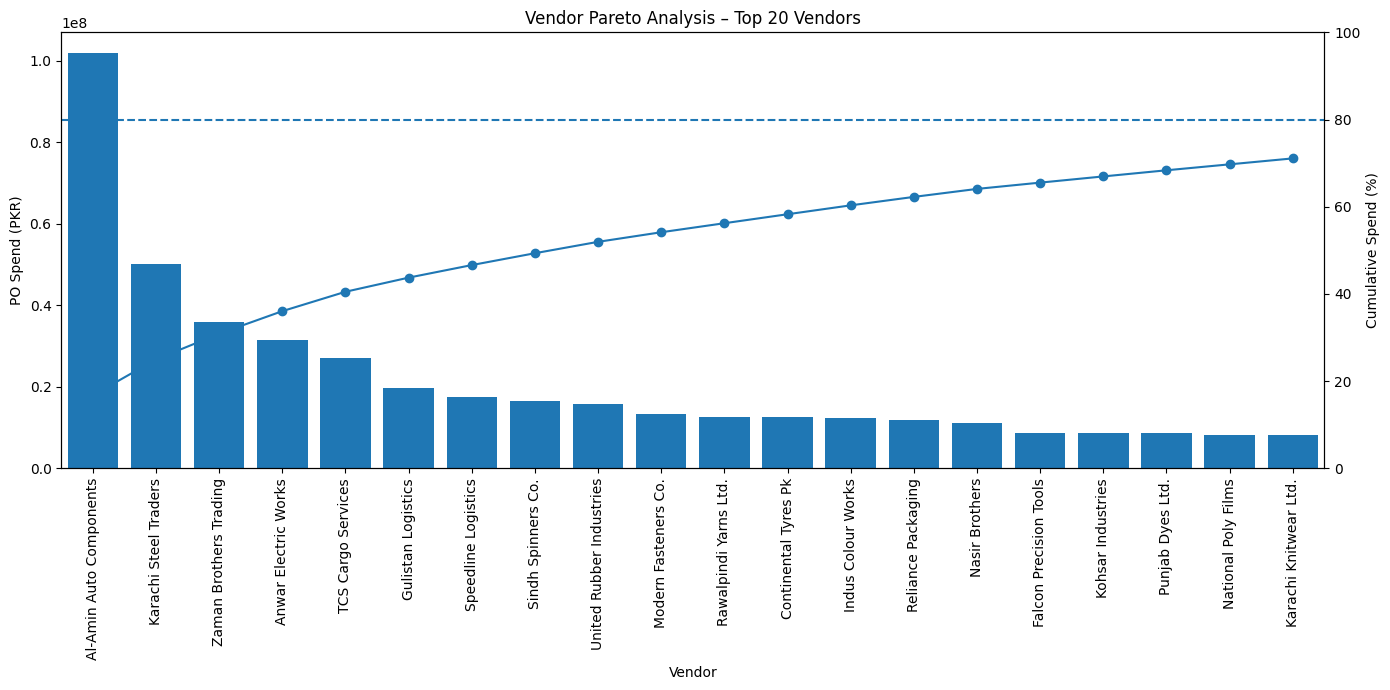

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total spend for each vendor
vendor_spend = (
    df.groupby("Vendor")["PO Value (PKR)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calculate percentage of total spend
vendor_spend["Spend Percentage"] = (
    vendor_spend["PO Value (PKR)"] / vendor_spend["PO Value (PKR)"].sum()
) * 100

# Calculate cumulative spend percentage
vendor_spend["Cumulative Spend Percentage"] = (
    vendor_spend["Spend Percentage"].cumsum()
)

# Add vendor rank
vendor_spend["Vendor Rank"] = range(1, len(vendor_spend) + 1)

# Identify vendors that bring cumulative spend to approximately 80%
vendors_80 = vendor_spend[
    vendor_spend["Cumulative Spend Percentage"] <= 80
].copy()

# Include the first vendor that crosses 80%
if len(vendors_80) < len(vendor_spend):
    vendors_80 = pd.concat([
        vendors_80,
        vendor_spend.iloc[[len(vendors_80)]]
    ])

# Display the Pareto table
print("===== VENDOR PARETO ANALYSIS =====")

display(
    vendor_spend[
        [
            "Vendor Rank",
            "Vendor",
            "PO Value (PKR)",
            "Spend Percentage",
            "Cumulative Spend Percentage"
        ]
    ].head(20)
)

# Display vendors contributing approximately 80% of total spend
print("\n===== VENDORS CONTRIBUTING APPROXIMATELY 80% OF TOTAL SPEND =====")

display(
    vendors_80[
        [
            "Vendor Rank",
            "Vendor",
            "PO Value (PKR)",
            "Spend Percentage",
            "Cumulative Spend Percentage"
        ]
    ]
)

print(
    f"\nNumber of vendors needed to reach approximately 80% of spend: "
    f"{len(vendors_80)}"
)

print(
    f"Cumulative spend of these vendors: "
    f"{vendors_80['Cumulative Spend Percentage'].iloc[-1]:.2f}%"
)

# -----------------------------
# Pareto Chart
# -----------------------------

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart: vendor spend
ax1.bar(
    vendor_spend["Vendor"],
    vendor_spend["PO Value (PKR)"]
)

ax1.set_xlabel("Vendor")
ax1.set_ylabel("PO Spend (PKR)")
ax1.tick_params(axis="x", rotation=90)

# Only show first 20 vendors for readability
ax1.set_xlim(-0.5, 19.5)

# Line chart: cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    vendor_spend["Vendor"].head(20),
    vendor_spend["Cumulative Spend Percentage"].head(20),
    marker="o"
)

ax2.set_ylabel("Cumulative Spend (%)")
ax2.set_ylim(0, 100)

# 80% reference line
ax2.axhline(
    y=80,
    linestyle="--"
)

plt.title("Vendor Pareto Analysis – Top 20 Vendors")
plt.tight_layout()
plt.show()